# BSDS500 Edge Detection — Logistic Regression vs SVM

**Aim:** Turn the BSDS500 image dataset into a pixel-level binary classification
problem (edge vs non-edge), train Logistic Regression and an SVM (RBF kernel)
on it, and compare them on Accuracy, Precision, Recall, F1-score and ROC-AUC.

**Fixes made to the original script** (kept everything else the same):
1. The data path was hardcoded to one Windows user's folder
   (`C:\Users\BIT\Downloads`) — replaced with a path you set once at the top,
   with a clear check that fails early (not mid-run) if it's wrong.
2. `SVC(probability=True)` on ~44,000 training pixels is very slow: `probability=True`
   makes libsvm run an internal 5-fold Platt-scaling calibration on top of the
   already-expensive RBF kernel training — this is almost certainly why the
   original run stalled right after printing "Training SVM...". Fixed by training
   with `probability=False` and using `decision_function()` scores for ROC-AUC
   instead — `roc_auc_score` only needs a score that *ranks* points correctly, it
   doesn't need a calibrated probability, so this is both faster and still correct.
3. Per-image debug printing is now a single on/off flag (default off) instead of
   always-on console spam.
4. Results are collected into one pandas table instead of hand-built print strings.


In [4]:
import sys
!{sys.executable} -m pip install numpy pandas opencv-python scipy scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.9 MB 3.4 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/11.9 MB 3.3 MB/s eta 0:00:04
   ----- ---------------------------------- 1.6/11.9 MB 2.9 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.9 MB 2.7 MB/s eta 0:00:04
   -------- ------------------------------- 2.6/11.9 MB 2.7 MB/s eta 0:00:04
   ----------- ---------------------------- 3.4/11.9 MB 2.8 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/11.9 MB 2.7 MB/s eta 0:00:04
   -------------- ------------------------- 4.5/11.9 MB 2.8 MB/s eta 0:00:03
   ----------------- ---------------------- 5.2/11.9 MB 2.8 MB/s eta 0:00:03
   -------------------- ------------------- 6.0/11.9 MB 2.9 MB/s eta 0:00:03
   ---------------------- ----------------- 6.6/11.9 MB 2.9 MB/s eta 0:00:02
   ------------------------- -------------- 7.6/11.9 MB 3.1 MB/s eta 0:00:02
   ---


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import glob
import numpy as np
import pandas as pd
import cv2
from scipy import io as sio
from skimage.filters import sobel
from skimage.color import rgb2gray

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report
)
import matplotlib.pyplot as plt


In [ ]:

DATA_ROOT  = "C:/Users/BIT/Downloads/archive (1) (1)"                               
IMAGES_DIR = os.path.join(DATA_ROOT, "images", "train")     
GT_DIR     = os.path.join(DATA_ROOT, "ground_truth", "train")

N_IMAGES_TO_USE  = 15      
PIXELS_PER_IMAGE = 4000    
RANDOM_STATE     = 42
DEBUG            = False   

if not os.path.isdir(IMAGES_DIR) or not os.path.isdir(GT_DIR):
    raise FileNotFoundError(
        f"Could not find:\n  {IMAGES_DIR}\n  {GT_DIR}\n"
        "Download BSDS500, unzip it, and set DATA_ROOT above to its location. "
        "Kaggle mirrors usually nest train/val/test under both images/ and "
        "ground_truth/ — run `os.listdir(DATA_ROOT)` to confirm the exact names."
    )


## 1. Ground truth loading

Each BSDS500 image ships with 5–7 *human-drawn* boundary maps (different people
traced the same image's edges slightly differently). We average across
annotators to get a soft edge map, then threshold it to get one binary
edge/non-edge label per pixel.

In [8]:
def load_ground_truth_mat(mat_path, debug=False):
    """Average the boundary maps of all annotators, then threshold at 0.3."""
    mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    gt = mat["groundTruth"]

    boundary_maps = [np.asarray(a.Boundaries, dtype=np.float32) for a in np.atleast_1d(gt)]
    avg_boundary = np.mean(boundary_maps, axis=0)
    binary_edges = (avg_boundary > 0.3).astype(np.uint8)

    if debug:
        print(f"  [debug] {len(boundary_maps)} annotators, "
              f"edge px={binary_edges.sum()}, non-edge px={(binary_edges == 0).sum()}")
    return binary_edges


def load_ground_truth_png(png_path):
    """Alternative loader if your Kaggle mirror ships PNG boundary masks instead of .mat."""
    mask = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
    return (mask > 127).astype(np.uint8)


## 2. Feature extraction — turning each pixel into a feature vector

A raw image is (Height × Width × 3) RGB values. To classify a *pixel* as
edge/non-edge, each pixel gets its own small feature vector describing its
color and its local neighborhood:

- **R, G, B** — raw color at that pixel
- **grayscale intensity** — brightness
- **Sobel gradient magnitude** — how sharply intensity changes around that
  pixel (edges have high gradient, flat regions have low gradient)
- **local standard deviation** (5×5 window) — a cheap texture measure (edges
  and textured regions vary more locally than smooth regions)

So one image of shape (H, W, 3) becomes a feature *volume* of shape (H, W, 6),
and every pixel is one row of a length-6 feature vector once we flatten it.

In [9]:
def extract_features(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    gray = rgb2gray(img_rgb)
    grad_mag = sobel(gray)

    mean = cv2.blur(gray, (5, 5))
    mean_sq = cv2.blur(gray ** 2, (5, 5))
    local_std = np.sqrt(np.maximum(mean_sq - mean ** 2, 0))

    features = np.dstack([
        img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2],
        gray, grad_mag, local_std
    ])
    return features  # shape (H, W, 6)


## 3. Building the pixel-level dataset

For each image: compute its (H, W, 6) feature volume, find which pixel
coordinates are labeled edge vs non-edge from the ground truth, and randomly
sample an equal number of each (so the final dataset is class-balanced rather
than the ~2–3% edge pixels you'd get from raw images). Stack every sampled
pixel's 6 features as one row of X, with its label (1=edge, 0=non-edge) in y.

In [10]:
def build_dataset(images_dir, gt_dir, n_images, pixels_per_image, seed, debug=False):
    rng = np.random.RandomState(seed)
    image_paths = sorted(glob.glob(os.path.join(images_dir, "*.jpg")))[:n_images]
    print(f"Found {len(image_paths)} candidate images to process.")

    X_list, y_list = [], []

    for img_path in image_paths:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        mat_path = os.path.join(gt_dir, base_name + ".mat")
        if not os.path.exists(mat_path):
            print(f"  [skip] {base_name}: no matching .mat file")
            continue

        img = cv2.imread(img_path)
        if img is None:
            print(f"  [skip] {base_name}: cv2.imread failed")
            continue

        try:
            edges = load_ground_truth_mat(mat_path, debug=debug)
        except Exception as e:
            print(f"  [skip] {base_name}: failed to parse ground truth ({e})")
            continue

        feats = extract_features(img)
        edge_idx = np.argwhere(edges == 1)
        non_edge_idx = np.argwhere(edges == 0)

        n_each = pixels_per_image // 2
        if len(edge_idx) == 0 or len(non_edge_idx) == 0:
            print(f"  [skip] {base_name}: one class is empty")
            continue

        edge_sample = edge_idx[rng.choice(len(edge_idx), min(n_each, len(edge_idx)), replace=False)]
        non_edge_sample = non_edge_idx[rng.choice(len(non_edge_idx), min(n_each, len(non_edge_idx)), replace=False)]

        for (r, c) in edge_sample:
            X_list.append(feats[r, c, :]); y_list.append(1)
        for (r, c) in non_edge_sample:
            X_list.append(feats[r, c, :]); y_list.append(0)

    return np.array(X_list), np.array(y_list)


print("Loading BSDS500 and building pixel-level edge/non-edge dataset...")
X, y = build_dataset(IMAGES_DIR, GT_DIR, N_IMAGES_TO_USE, PIXELS_PER_IMAGE, RANDOM_STATE, debug=DEBUG)
print(f"Dataset shape: X={X.shape}, y={y.shape}, positive rate={y.mean():.3f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")


Loading BSDS500 and building pixel-level edge/non-edge dataset...
Found 15 candidate images to process.
Dataset shape: X=(58560, 6), y=(58560,), positive rate=0.488
Train: (43920, 6), Test: (14640, 6)


## 4. Train Logistic Regression and SVM, score both the same way

`get_scores()` returns, for either model, a per-pixel score where *higher =
more likely edge* — `predict_proba` for Logistic Regression,
`decision_function` for the SVM (avoids the slow internal probability
calibration; `roc_auc_score`/`roc_curve` only need correctly-ranked scores,
not calibrated probabilities).

In [11]:
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM (RBF kernel)": SVC(kernel="rbf", probability=False, random_state=RANDOM_STATE),
}

results = {}
roc_curves = {}

for name, model in models.items():
    print(f"\nTraining {name} ...")
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    scores = get_scores(model, X_test_s)

    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, scores),
    }
    roc_curves[name] = roc_curve(y_test, scores)

    print(classification_report(y_test, y_pred, target_names=["Non-Edge", "Edge"]))



Training Logistic Regression ...
              precision    recall  f1-score   support

    Non-Edge       0.69      0.81      0.75      7500
        Edge       0.75      0.63      0.68      7140

    accuracy                           0.72     14640
   macro avg       0.72      0.72      0.71     14640
weighted avg       0.72      0.72      0.72     14640


Training SVM (RBF kernel) ...
              precision    recall  f1-score   support

    Non-Edge       0.76      0.76      0.76      7500
        Edge       0.75      0.74      0.74      7140

    accuracy                           0.75     14640
   macro avg       0.75      0.75      0.75     14640
weighted avg       0.75      0.75      0.75     14640



## 5. Comparison table

In [12]:
summary = pd.DataFrame(results).T.round(4)
summary


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7181,0.7546,0.6254,0.6839,0.7813
SVM (RBF kernel),0.7516,0.7462,0.7434,0.7448,0.8220


## 6. ROC curves

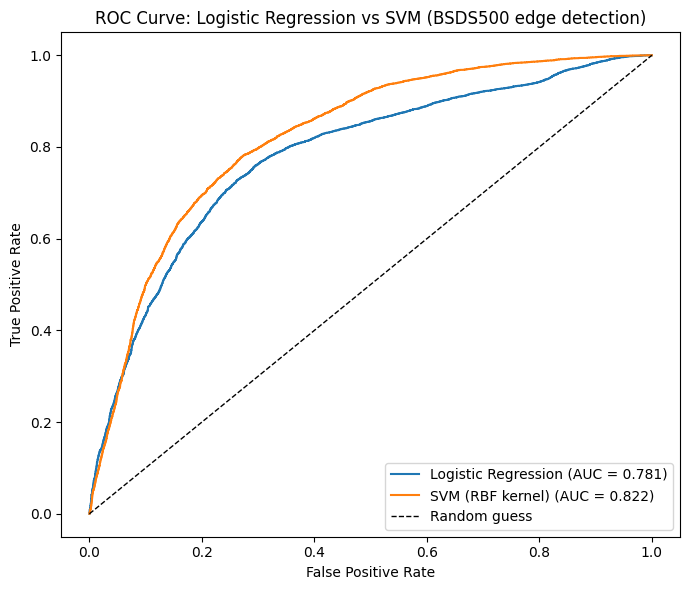

In [13]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, _) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression vs SVM (BSDS500 edge detection)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150)
plt.show()
